# CAT 2

**MOBILE PRICE RANGE**
**EAGER LEARNER : DECISION TREES**

Upload and clean data

In [2]:
from google.colab import files

uploaded = files.upload()

Saving MobilePriceRange.csv to MobilePriceRange.csv


## Data cleaning

In [3]:
import pandas as pd

mobile_data = pd.read_csv('MobilePriceRange.csv')
mobile_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BatteryPower    2000 non-null   int64  
 1   InternalMemory  2000 non-null   int64  
 2   ClockSpeed      2000 non-null   float64
 3   NoOfCores       2000 non-null   int64  
 4   RAM             2000 non-null   int64  
 5   TalkTime        2000 non-null   int64  
 6   DualSim         2000 non-null   int64  
 7   3G              2000 non-null   int64  
 8   4G              2000 non-null   int64  
 9   WiFi            2000 non-null   int64  
 10  Bluetooth       2000 non-null   int64  
 11  MobileDepth     2000 non-null   float64
 12  MobileWeight    2000 non-null   int64  
 13  TouchScreen     2000 non-null   int64  
 14  ScreenHeight    2000 non-null   int64  
 15  ScreenWidth     2000 non-null   int64  
 16  FrontCameraPx   2000 non-null   int64  
 17  RearCameraPX    2000 non-null   i

In [4]:
mobile_data.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,...,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight,PriceRange
0,842,7,2.2,2,2549,19,0,0,0,1,...,0.6,188,0,9,7,1,2,20,756,Medium
1,1021,53,0.5,3,2631,7,1,1,1,0,...,0.7,136,1,17,3,0,6,905,1988,High
2,563,41,0.5,5,2603,9,1,1,1,0,...,0.9,145,1,11,2,2,6,1263,1716,High
3,615,10,2.5,6,2769,11,0,1,0,0,...,0.8,131,0,16,8,0,9,1216,1786,High
4,1821,44,1.2,2,1411,15,0,1,1,0,...,0.6,141,1,8,2,13,14,1208,1212,Medium


In [5]:
cols = [
    "BatteryPower", "InternalMemory", "ClockSpeed", "NoOfCores", "RAM",
    "TalkTime", "MobileDepth", "MobileWeight", "ScreenHeight", "ScreenWidth",
    "FrontCameraPx", "RearCameraPX", "PxHeight", "PxWeight"
]

df = mobile_data[mobile_data[cols].gt(0).all(axis=1)]
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1393 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BatteryPower    1393 non-null   int64  
 1   InternalMemory  1393 non-null   int64  
 2   ClockSpeed      1393 non-null   float64
 3   NoOfCores       1393 non-null   int64  
 4   RAM             1393 non-null   int64  
 5   TalkTime        1393 non-null   int64  
 6   DualSim         1393 non-null   int64  
 7   3G              1393 non-null   int64  
 8   4G              1393 non-null   int64  
 9   WiFi            1393 non-null   int64  
 10  Bluetooth       1393 non-null   int64  
 11  MobileDepth     1393 non-null   float64
 12  MobileWeight    1393 non-null   int64  
 13  TouchScreen     1393 non-null   int64  
 14  ScreenHeight    1393 non-null   int64  
 15  ScreenWidth     1393 non-null   int64  
 16  FrontCameraPx   1393 non-null   int64  
 17  RearCameraPX    1393 non-null   int64 

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Dictionary to store outliers per column
outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Boolean mask for outliers
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)

    # Store outlier rows
    outliers_dict[col] = df[mask]

# Show how many outliers per column
for col in numeric_cols:
    print(f"{col}: {len(outliers_dict[col])} outliers")


BatteryPower: 0 outliers
InternalMemory: 0 outliers
ClockSpeed: 0 outliers
NoOfCores: 0 outliers
RAM: 0 outliers
TalkTime: 0 outliers
DualSim: 0 outliers
3G: 348 outliers
4G: 0 outliers
WiFi: 0 outliers
Bluetooth: 0 outliers
MobileDepth: 0 outliers
MobileWeight: 0 outliers
TouchScreen: 0 outliers
ScreenHeight: 0 outliers
ScreenWidth: 0 outliers
FrontCameraPx: 12 outliers
RearCameraPX: 0 outliers
PxHeight: 0 outliers
PxWeight: 0 outliers


<Axes: xlabel='PriceRange', ylabel='Count'>

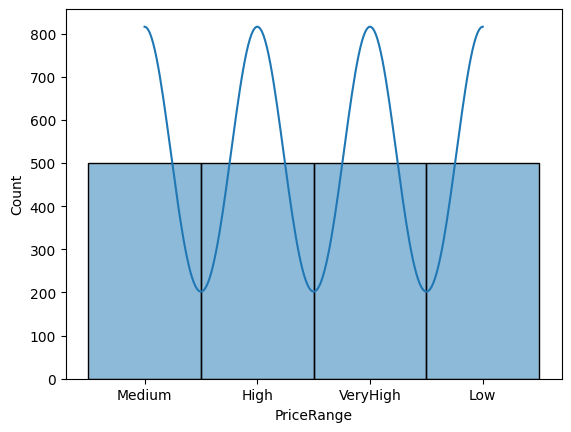

In [52]:
sns.histplot(mobile_data["PriceRange"], bins=30, kde=True)

In [16]:
for c in df.columns:
    print(f"\nColumn: {c}")
    print(df[c].value_counts().sort_index())



Column: BatteryPower
BatteryPower
501     2
502     2
503     2
504     3
506     1
       ..
1994    2
1995    2
1996    1
1997    1
1998    1
Name: count, Length: 894, dtype: int64

Column: InternalMemory
InternalMemory
2     29
3     19
4     15
5     23
6     31
      ..
60    18
61    19
62    17
63    21
64    19
Name: count, Length: 63, dtype: int64

Column: ClockSpeed
ClockSpeed
0.5    289
0.6     49
0.7     48
0.8     41
0.9     46
1.0     41
1.1     36
1.2     38
1.3     48
1.4     50
1.5     47
1.6     56
1.7     37
1.8     40
1.9     47
2.0     45
2.1     55
2.2     37
2.3     55
2.4     44
2.5     51
2.6     35
2.7     37
2.8     57
2.9     41
3.0     23
Name: count, dtype: int64

Column: NoOfCores
NoOfCores
1    179
2    171
3    170
4    178
5    178
6    162
7    177
8    178
Name: count, dtype: int64

Column: RAM
RAM
256     1
258     2
259     1
263     1
267     1
       ..
3971    1
3978    1
3991    2
3996    1
3998    1
Name: count, Length: 1174, dtype: int64

Co

In [17]:
df.duplicated()

,0
0,False
2,False
4,False
5,False
6,False
...,...
1992,False
1994,False
1997,False
1998,False


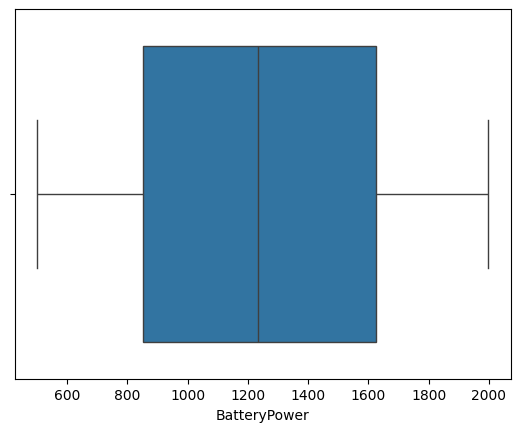

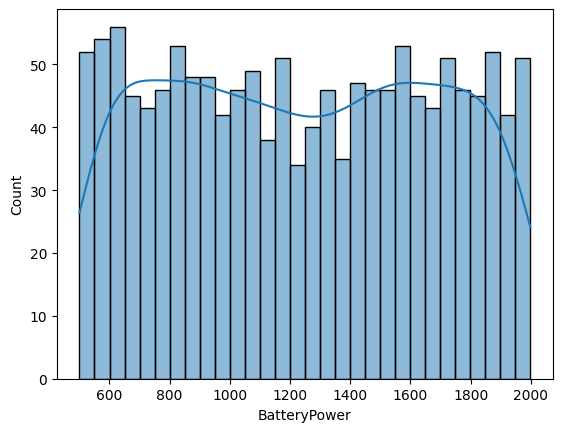

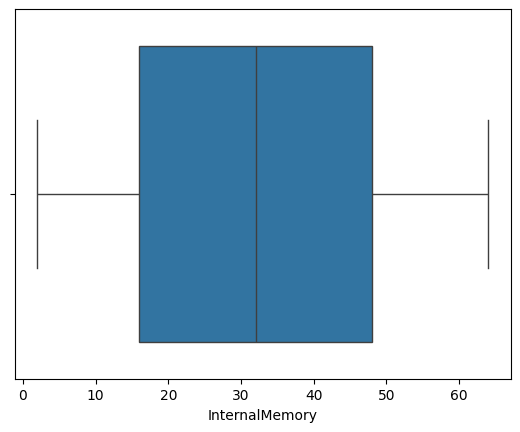

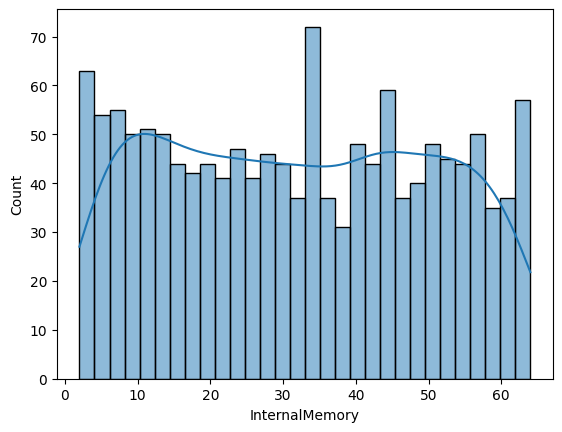

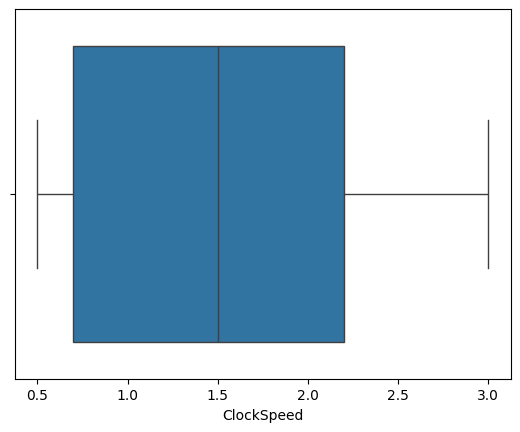

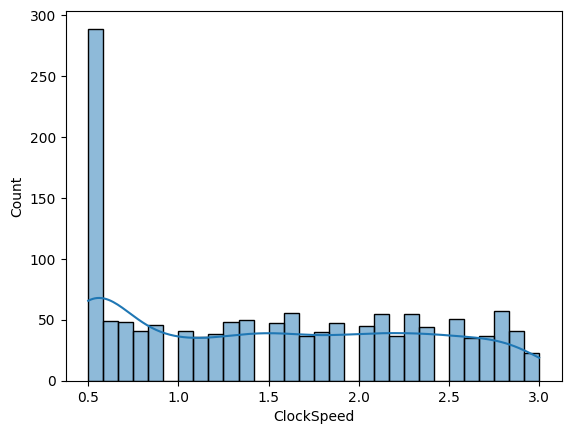

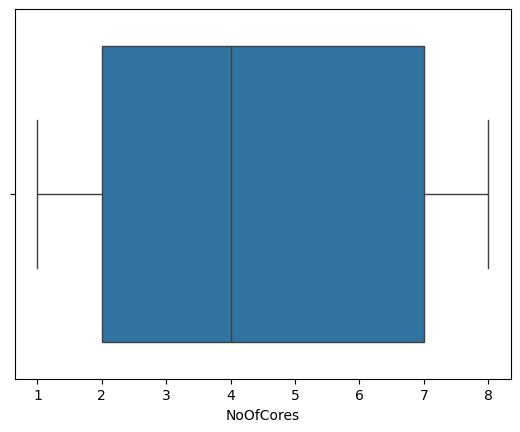

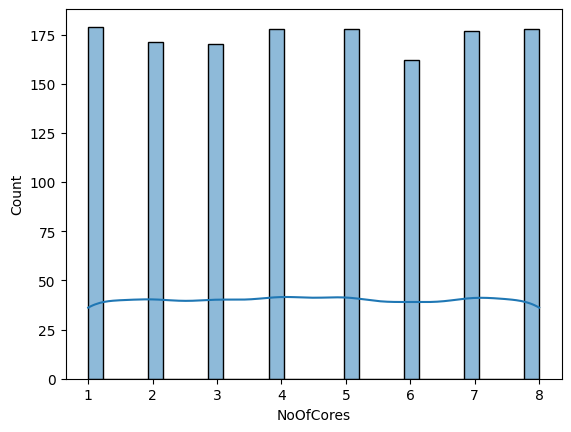

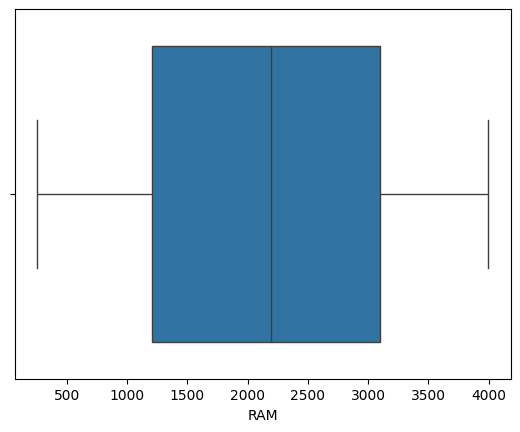

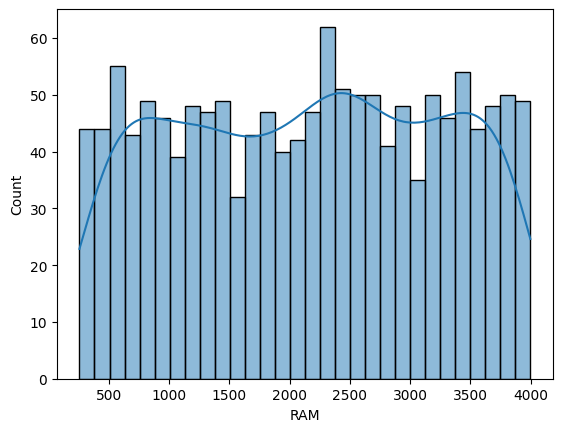

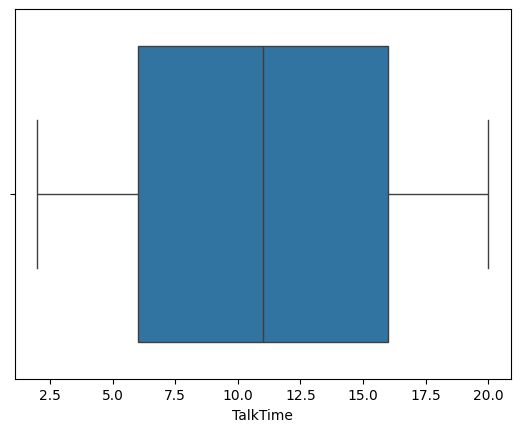

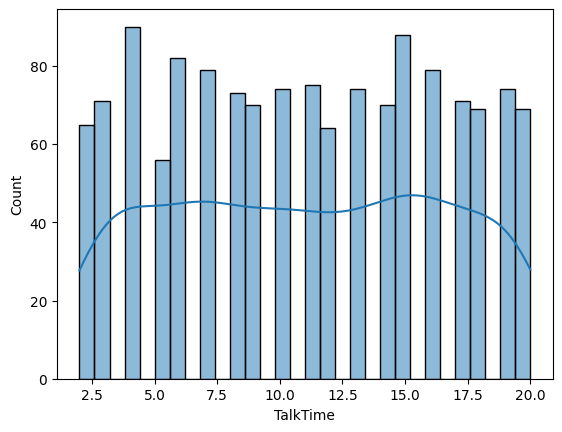

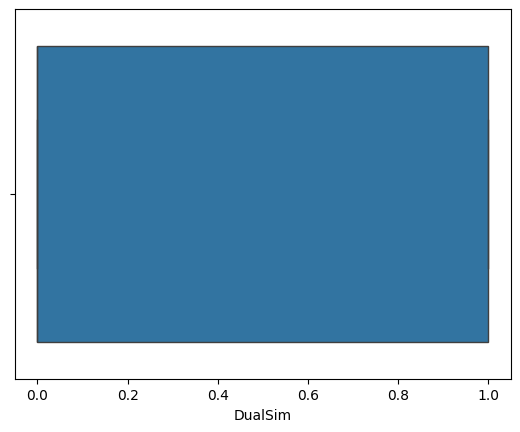

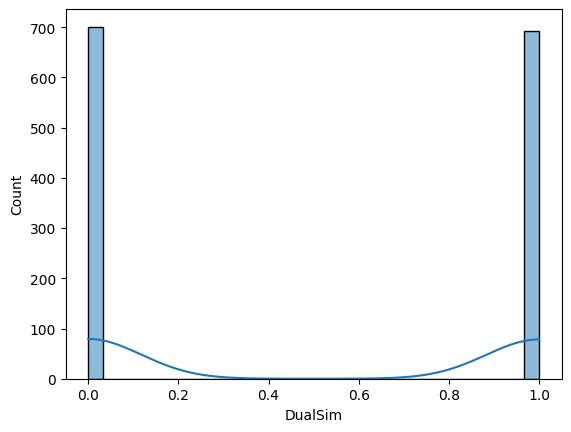

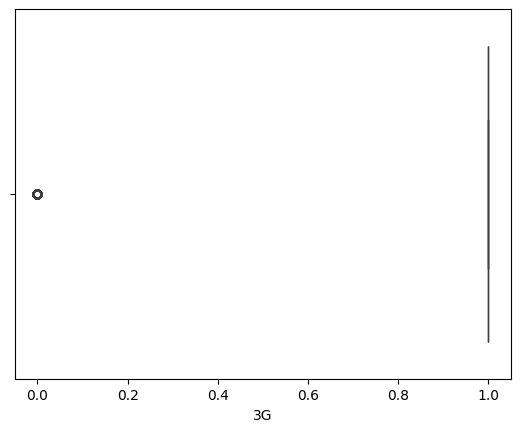

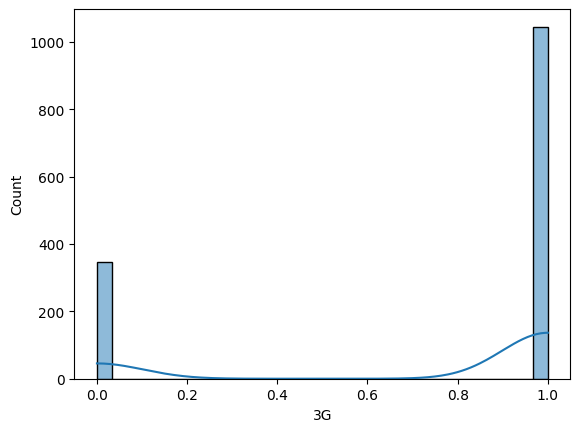

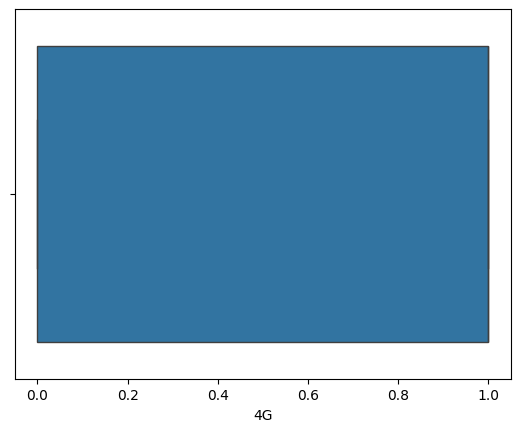

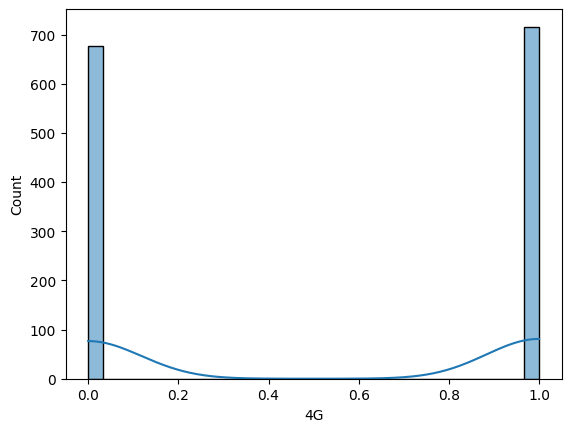

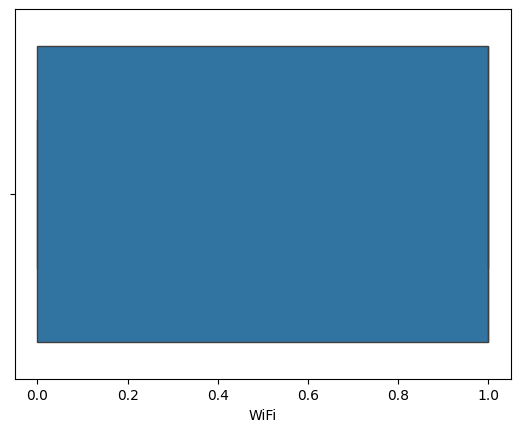

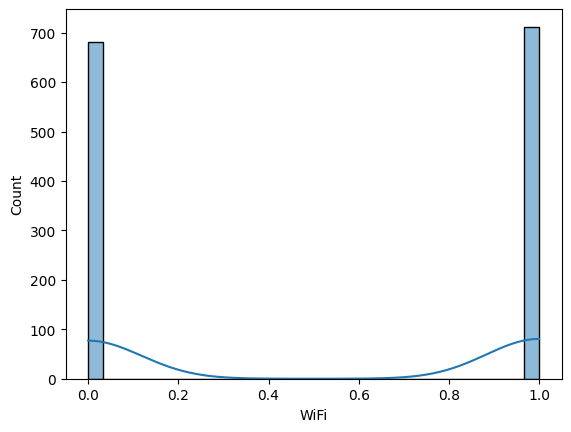

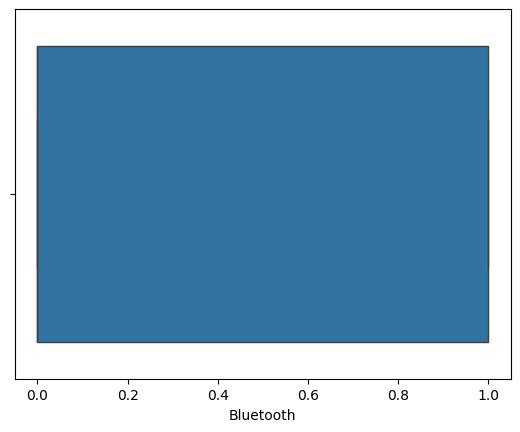

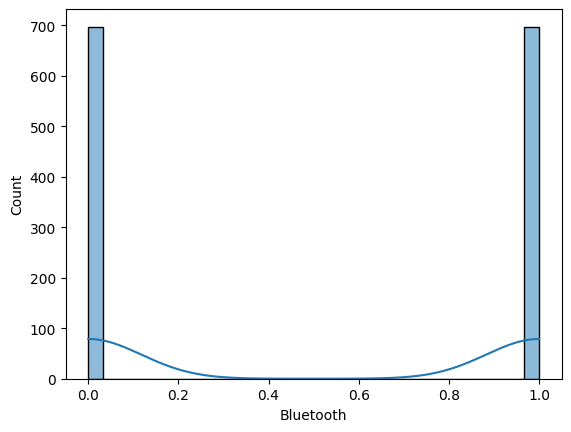

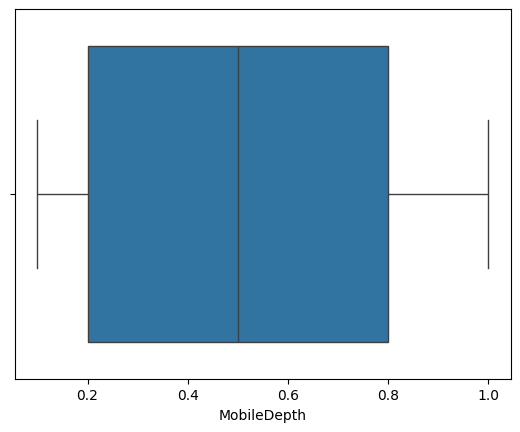

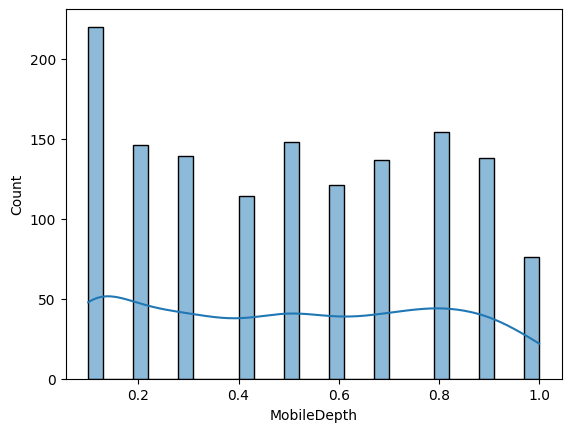

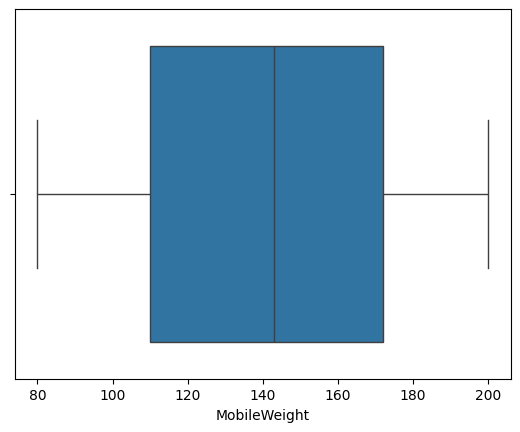

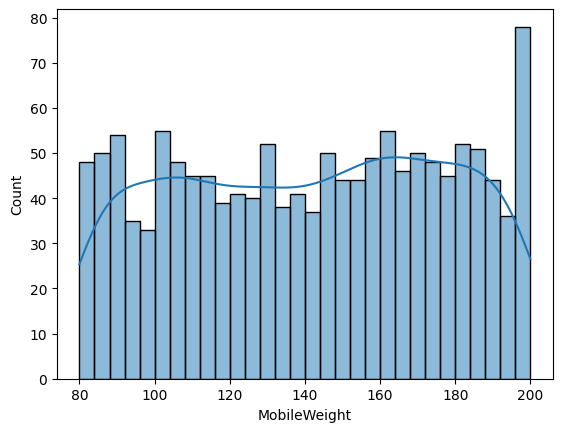

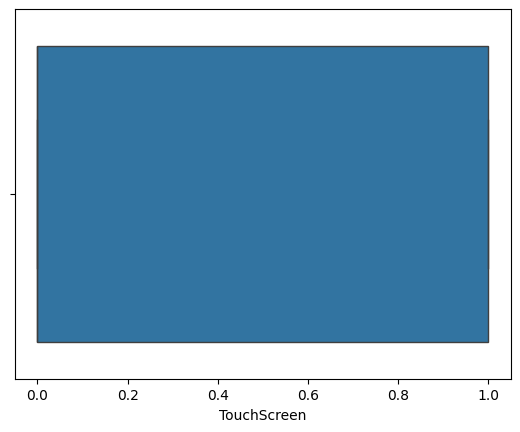

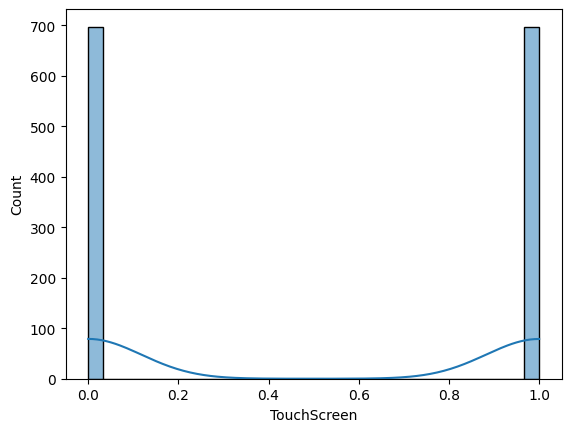

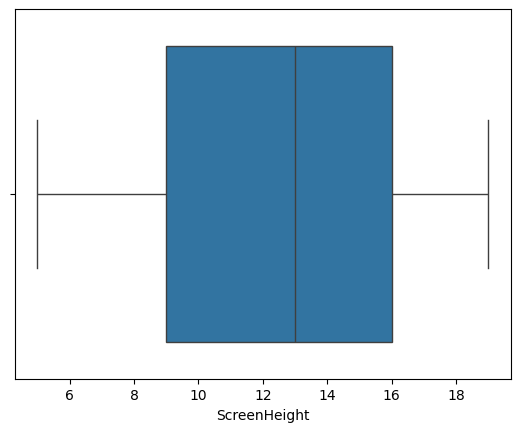

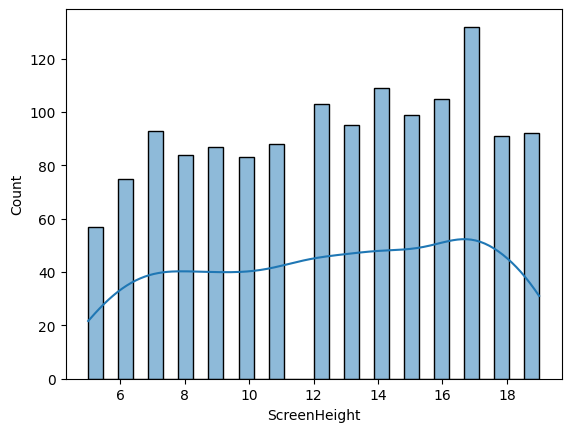

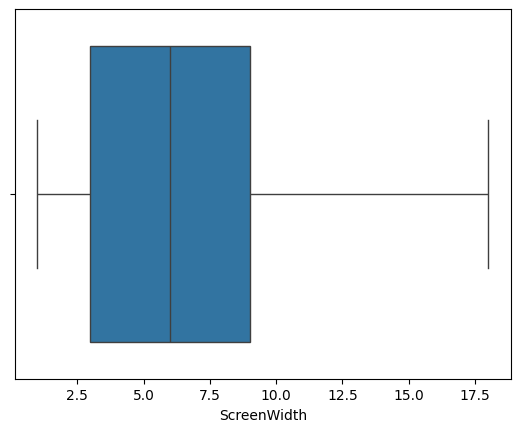

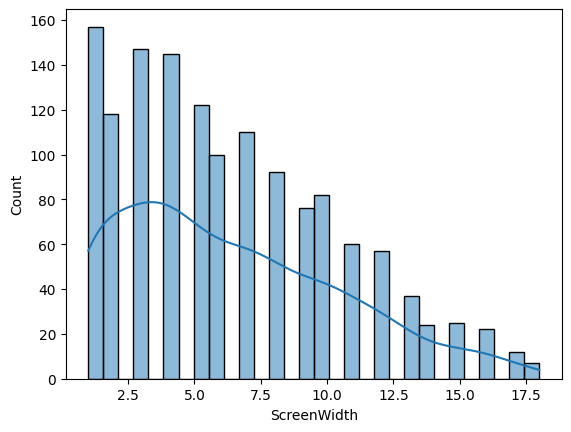

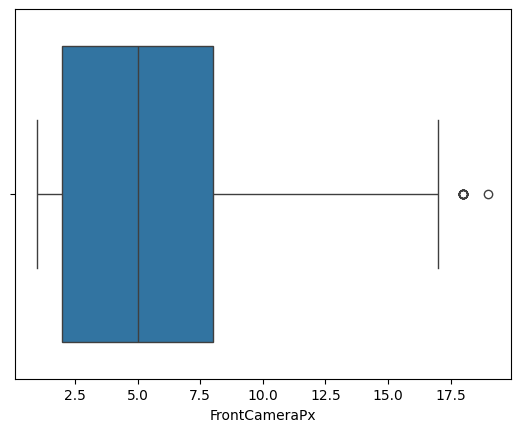

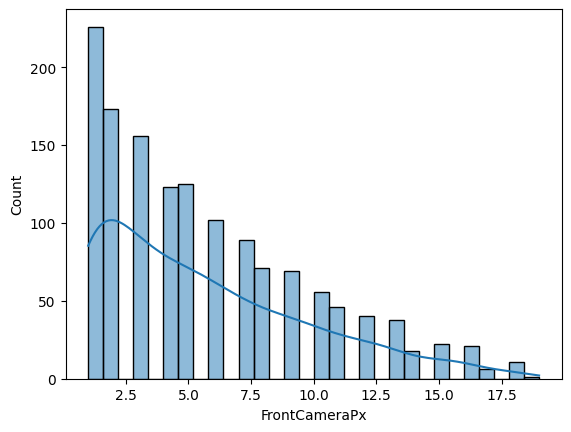

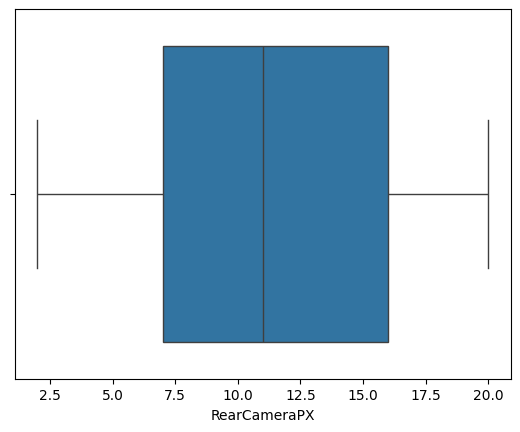

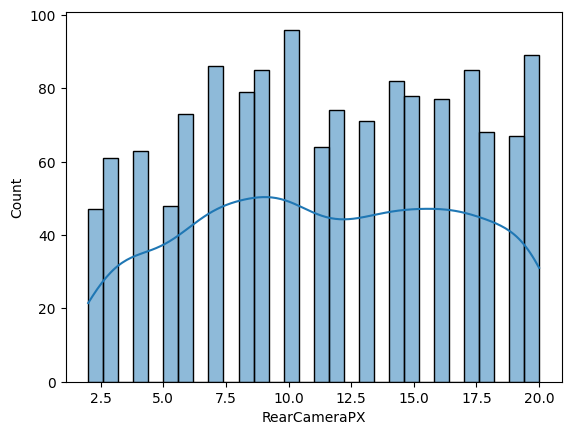

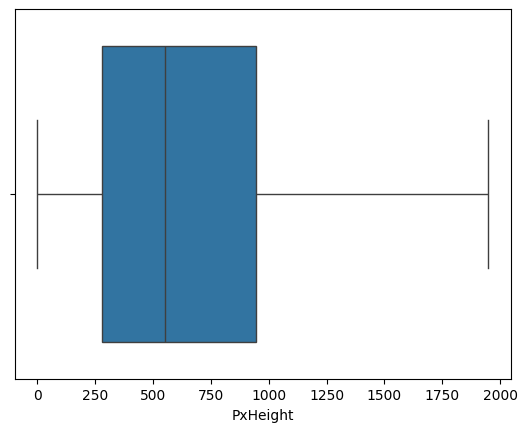

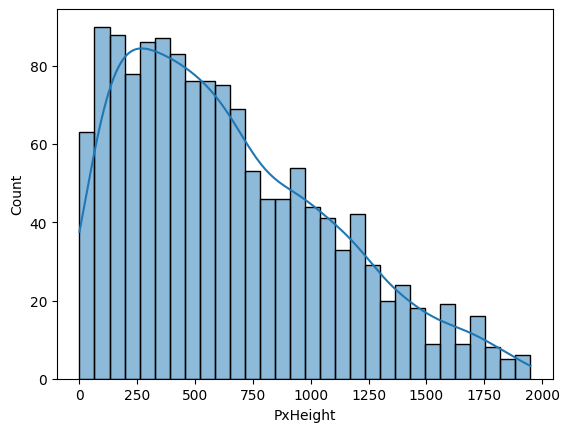

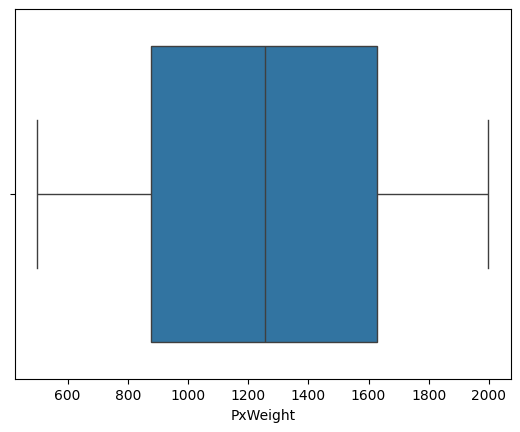

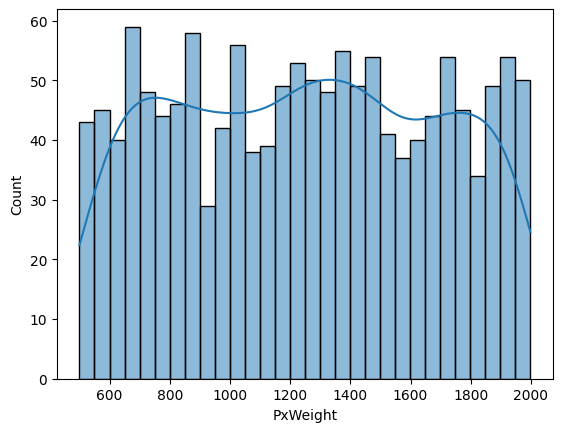

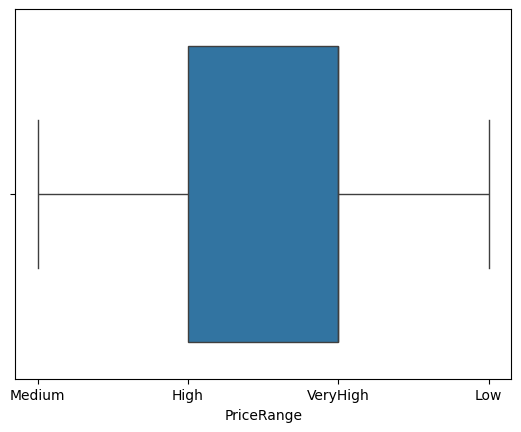

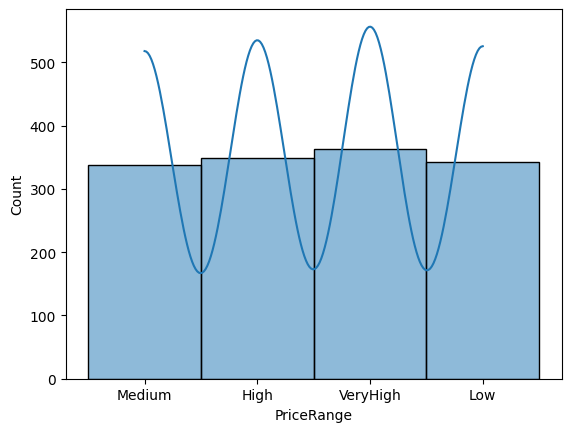

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns:
  sns.boxplot(x=df[col])
  plt.show()

  sns.histplot(df[col], bins=30, kde=True)
  plt.show()

## Exploratory Data Analysis

Columns with outliers: ['3G', 'FrontCameraPx']


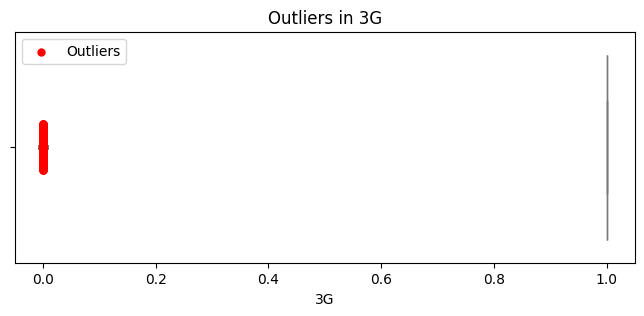

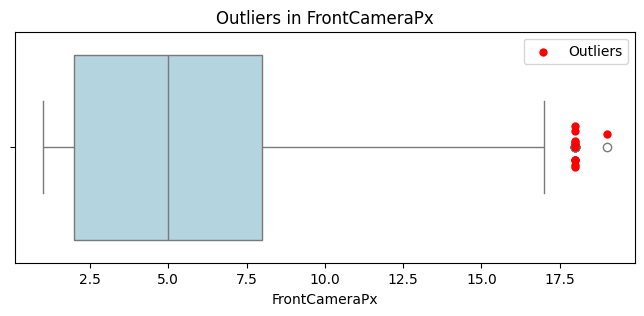

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get only the columns that actually have outliers
cols_with_outliers = [col for col, rows in outliers_dict.items() if len(rows) > 0]

print("Columns with outliers:", cols_with_outliers)

# Plot each outlier column
for col in cols_with_outliers:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col], color='lightblue')

    # Plot the outlier points on top
    sns.stripplot(x=outliers_dict[col][col], color='red', size=6, label="Outliers")

    plt.title(f"Outliers in {col}")
    plt.legend()
    plt.show()


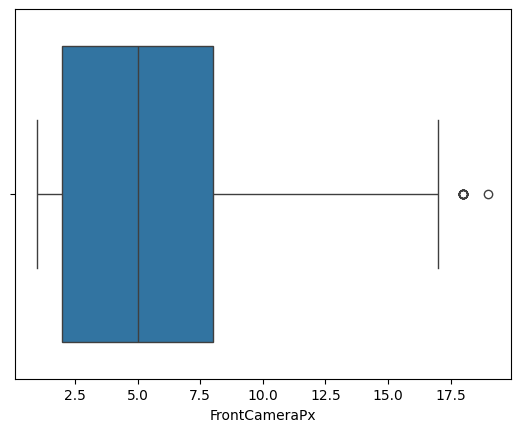

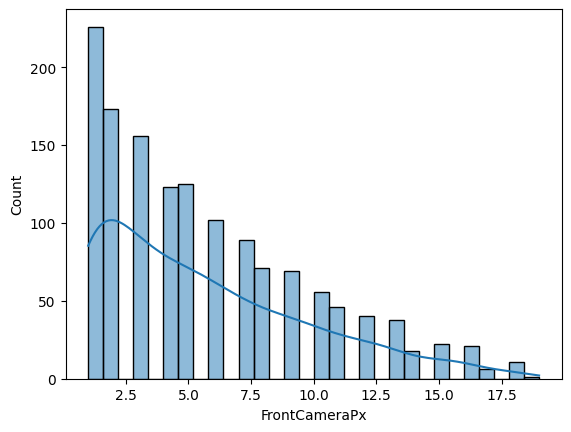

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["FrontCameraPx"])
plt.show()

sns.histplot(df["FrontCameraPx"], bins=30, kde=True)
plt.show()


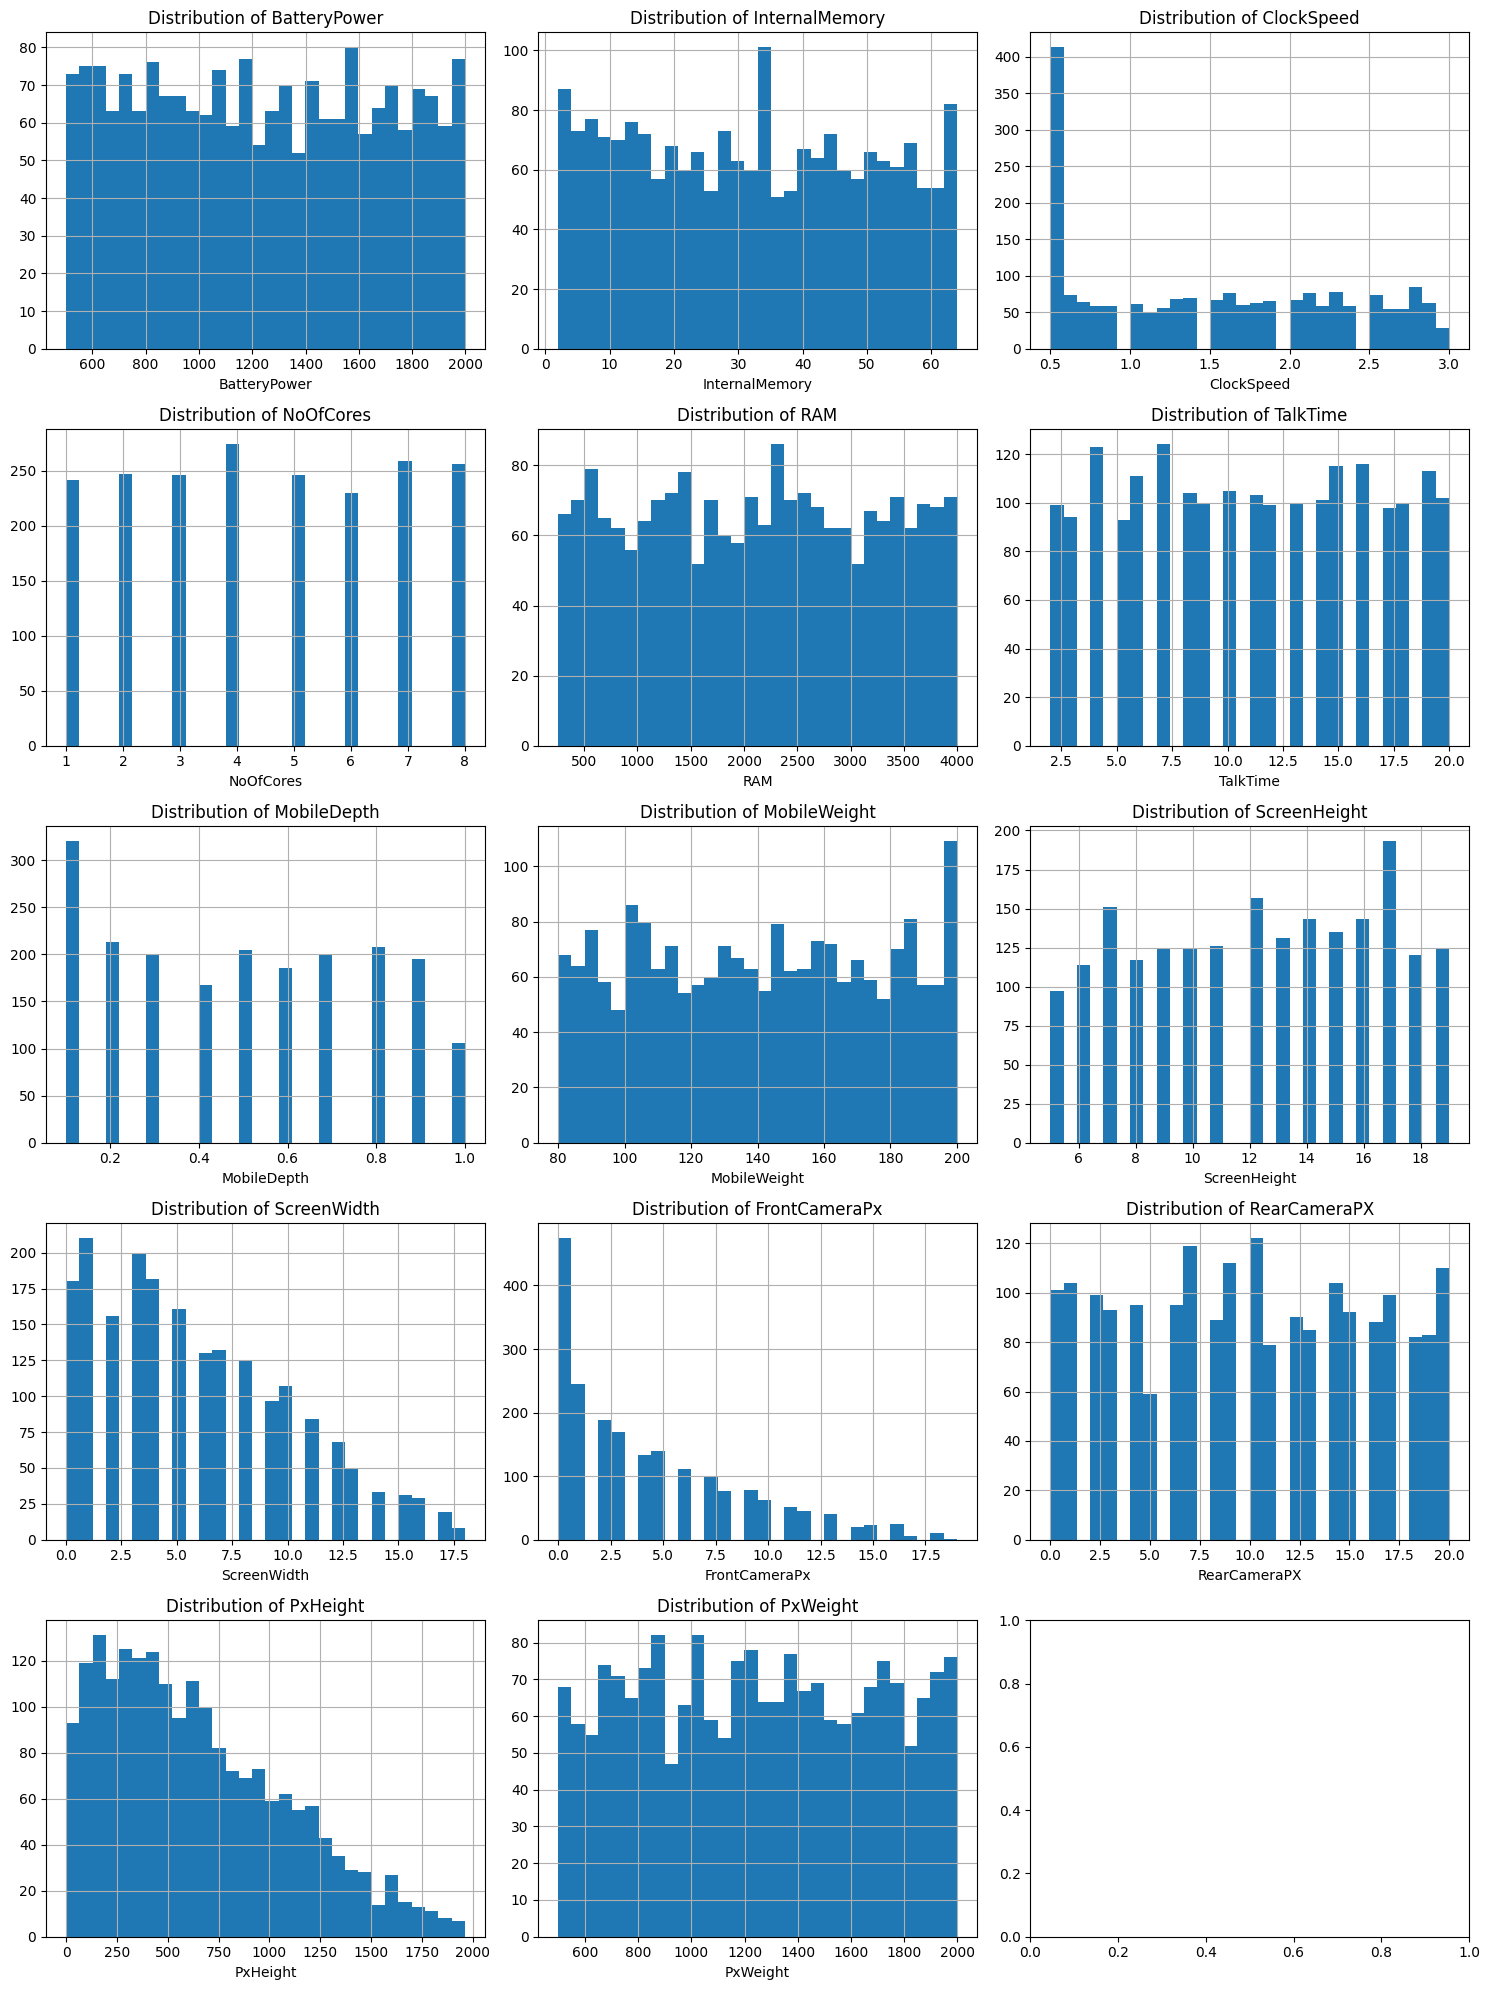

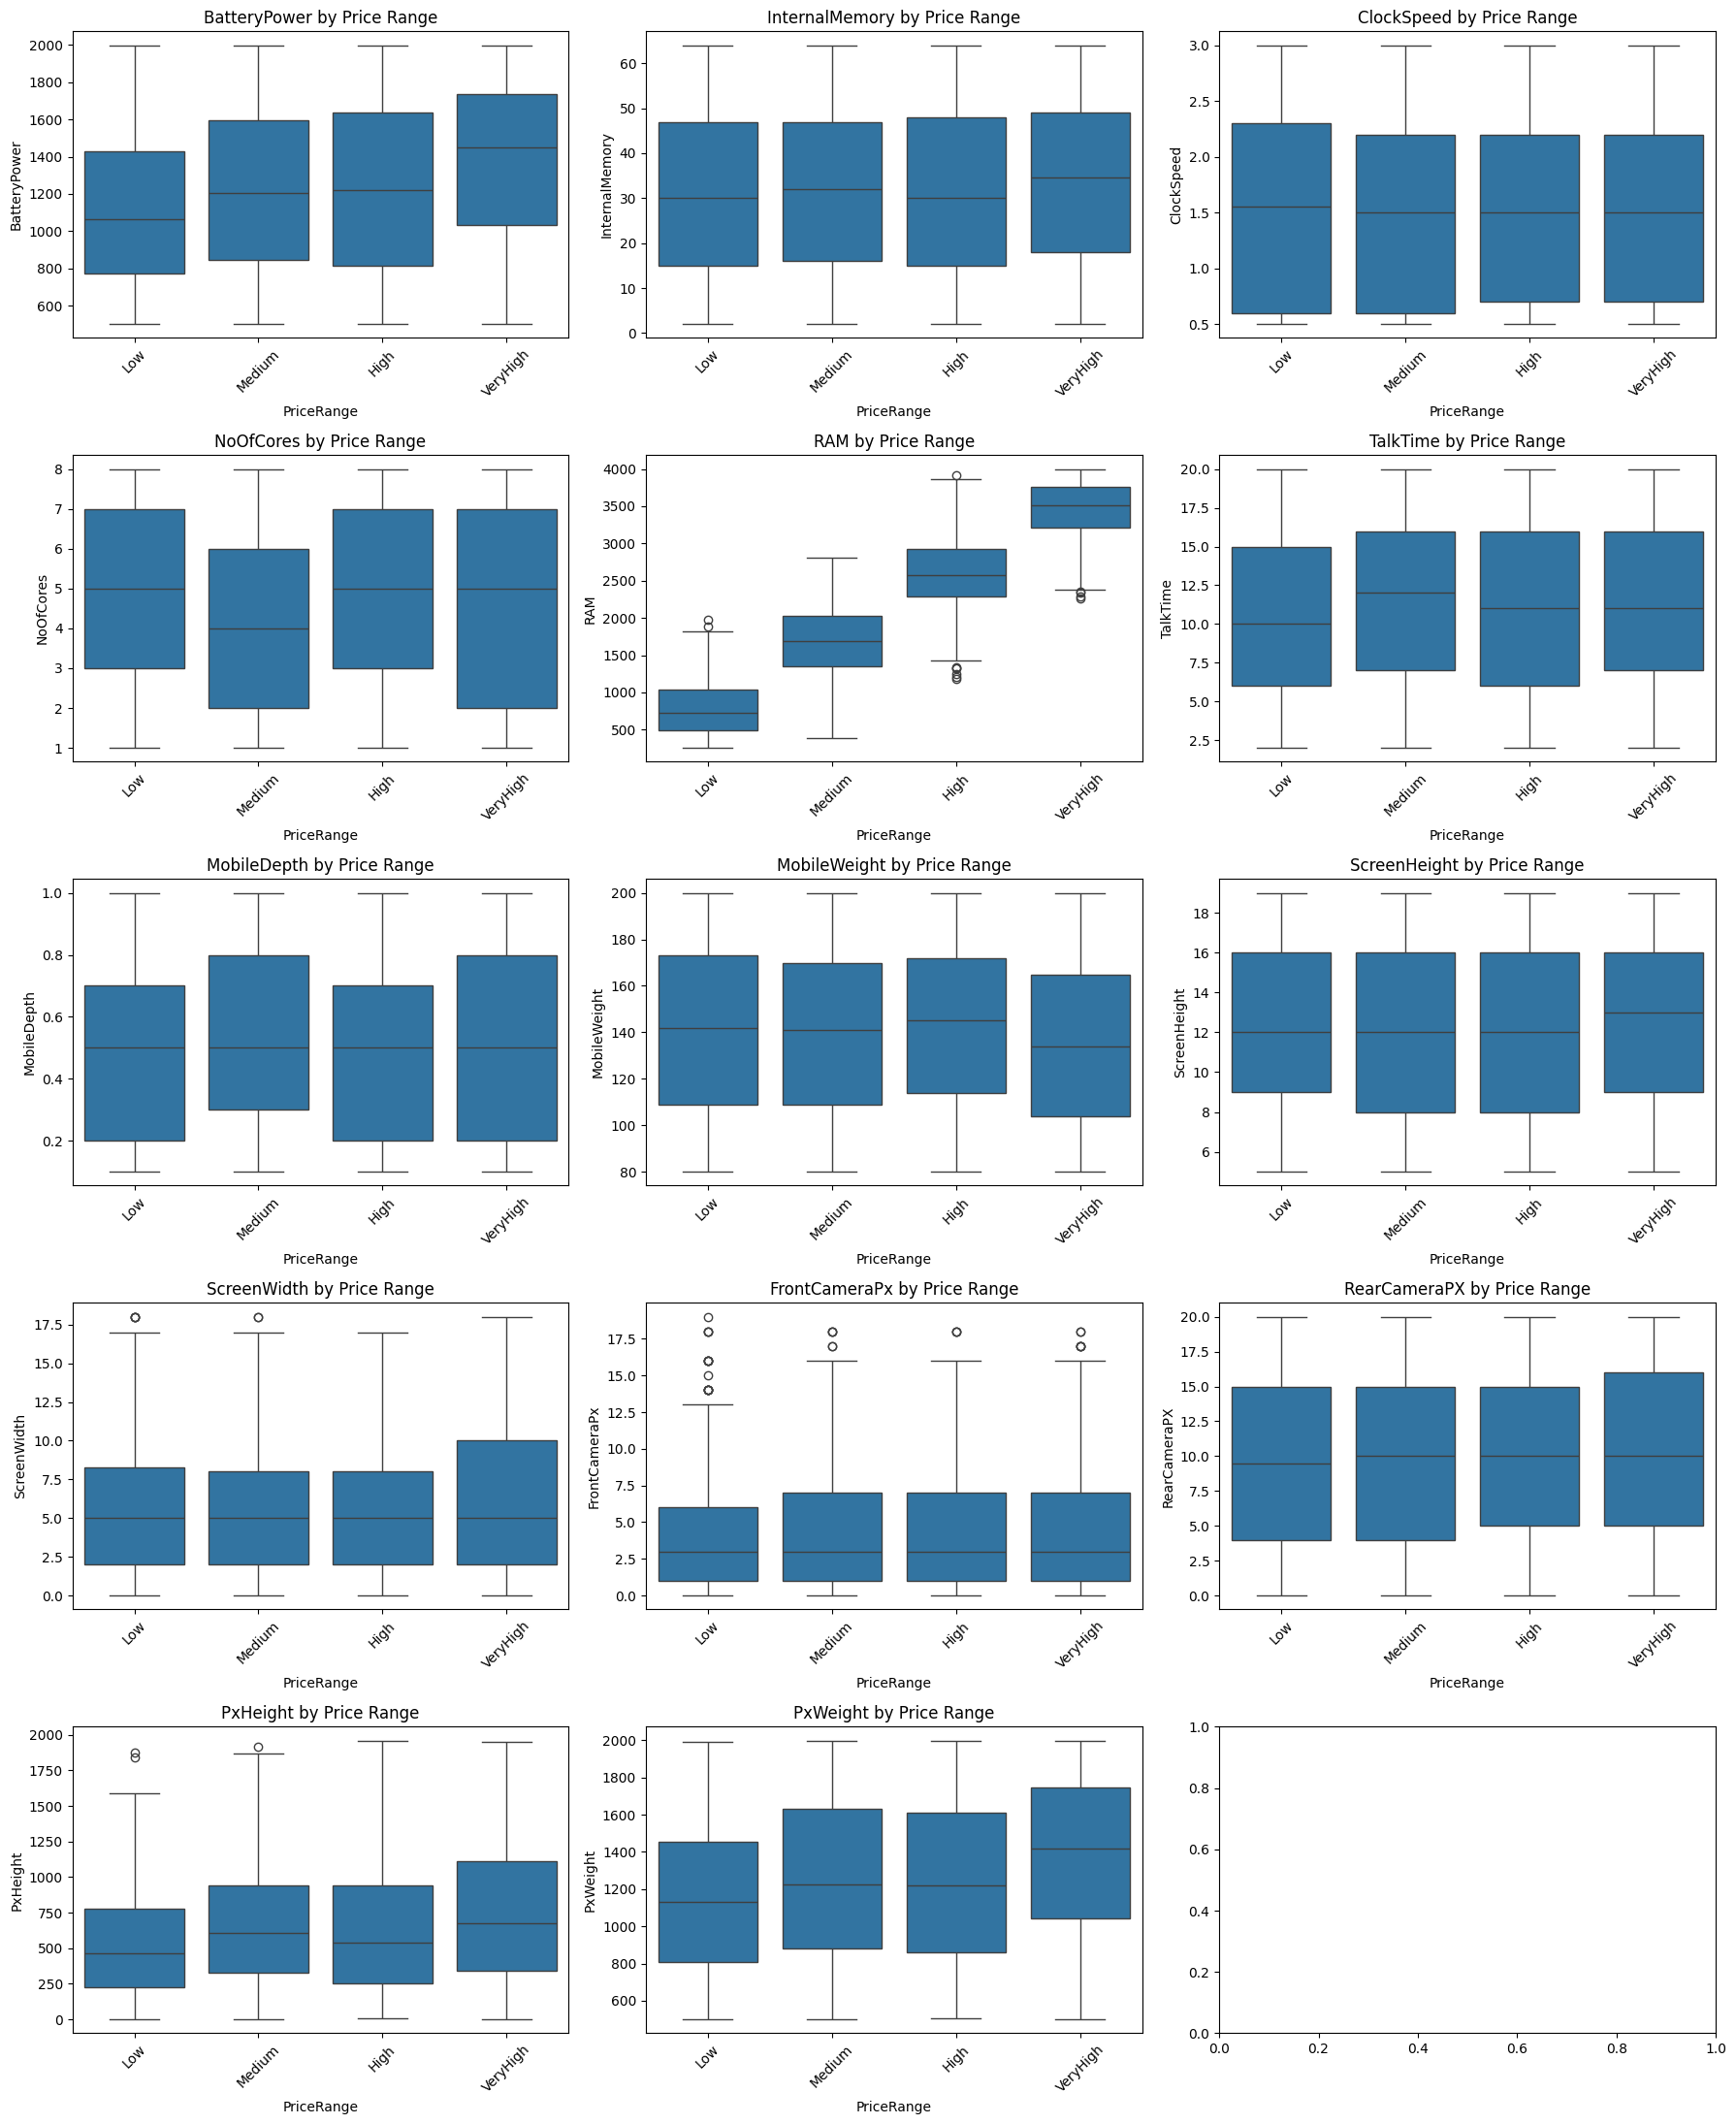

In [101]:
# Select numerical columns (excluding binary/categorical)
numerical_cols = ['BatteryPower', 'InternalMemory', 'ClockSpeed', 'NoOfCores',
                 'RAM', 'TalkTime', 'MobileDepth', 'MobileWeight',
                 'ScreenHeight', 'ScreenWidth', 'FrontCameraPx', 'RearCameraPX',
                 'PxHeight', 'PxWeight']

price_order = ["Low", "Medium", "High", "VeryHigh"]

# Convert column to ordered categorical
mobile_data["PriceRange"] = pd.Categorical(mobile_data["PriceRange"],
                                           categories=price_order,
                                           ordered=True)
# Distribution plots
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    mobile_data[col].hist(bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# Boxplots by PriceRange
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=mobile_data, x='PriceRange', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Price Range')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

K-NN

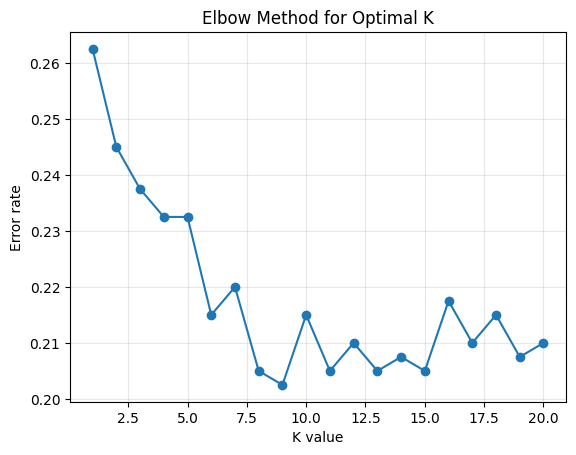

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"].map({"Low":0, "Medium":1, "High":2, "VeryHigh":3})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

errors = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    errors.append(1 - accuracy_score(y_test, preds))

plt.plot(k_values, errors, marker='o')
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.title("Elbow Method for Optimal K")
plt.grid(True, alpha=0.3)
plt.show()

PriceRange unique values: ['Medium' 'High' 'VeryHigh' 'Low']
PriceRange value counts:
 PriceRange
Medium      500
High        500
VeryHigh    500
Low         500
Name: count, dtype: int64

Dataset shape: (2000, 21)

Feature statistics:
       BatteryPower          RAM
count   2000.000000  2000.000000
mean    1238.518500  2124.213000
std      439.418206  1084.732044
min      501.000000   256.000000
25%      851.750000  1207.500000
50%     1226.000000  2146.500000
75%     1615.250000  3064.500000
max     1998.000000  3998.000000

Target distribution:
PriceRange
0    500
1    500
2    500
3    500
Name: count, dtype: int64

Random state 42 - Test set size: 400

Random state 123 - Test set size: 400


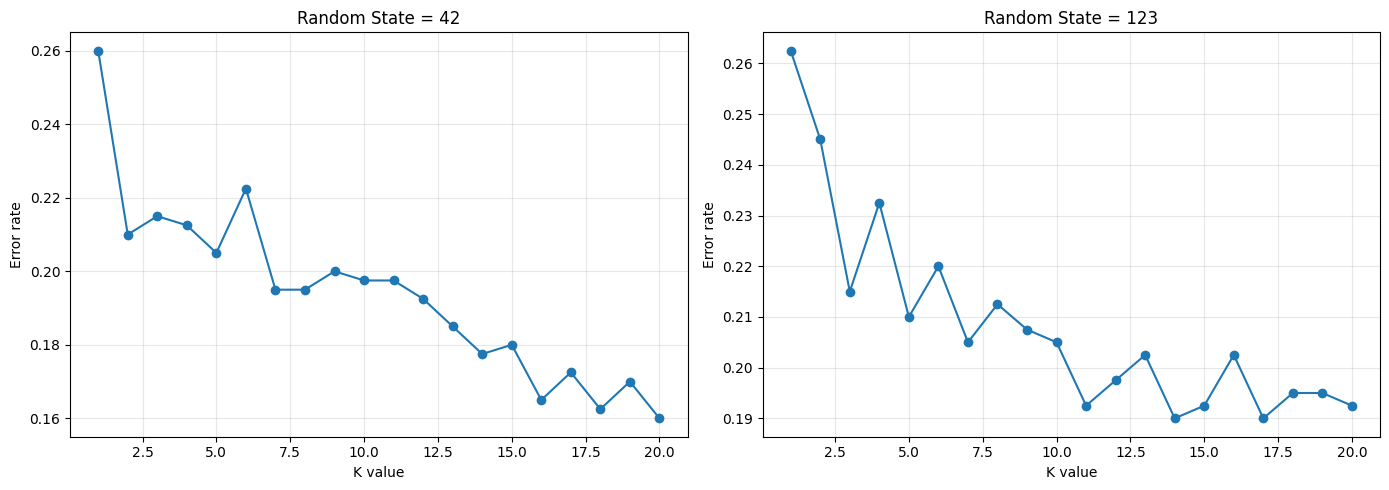

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# First, let's check what we're working with
print("PriceRange unique values:", mobile_data["PriceRange"].unique())
print("PriceRange value counts:\n", mobile_data["PriceRange"].value_counts())
print("\nDataset shape:", mobile_data.shape)

X = mobile_data[["BatteryPower", "RAM"]]
print("\nFeature statistics:")
print(X.describe())

# Check if PriceRange is already numeric
if mobile_data["PriceRange"].dtype in ['int64', 'float64']:
    y = mobile_data["PriceRange"]
else:
    y = mobile_data["PriceRange"].map({"Low":0, "Medium":1, "High":2, "VeryHigh":3})

print("\nTarget distribution:")
print(y.value_counts().sort_index())

# Try multiple random states to see if pattern persists
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, random_state in enumerate([42, 123]):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    errors = []
    k_values = range(1, 21)

    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        errors.append(1 - accuracy_score(y_test, preds))

    axes[idx].plot(k_values, errors, marker='o')
    axes[idx].set_xlabel("K value")
    axes[idx].set_ylabel("Error rate")
    axes[idx].set_title(f"Random State = {random_state}")
    axes[idx].grid(True, alpha=0.3)

    print(f"\nRandom state {random_state} - Test set size: {len(y_test)}")

plt.tight_layout()
plt.show()

In [44]:
print(mobile_data["PriceRange"].value_counts().sort_index())

PriceRange
High        500
Low         500
Medium      500
VeryHigh    500
Name: count, dtype: int64


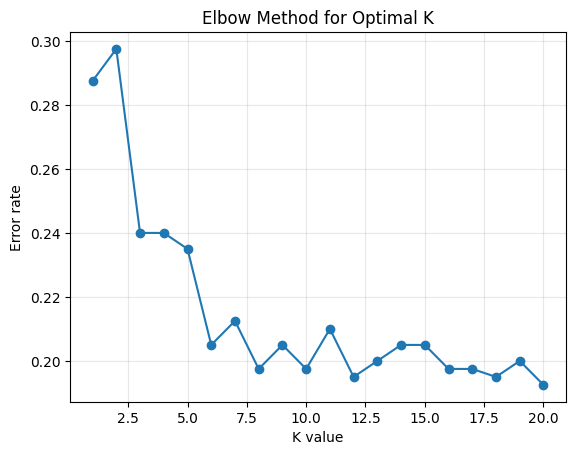

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = mobile_data[["PxWeight", "RAM"]]
y = mobile_data["PriceRange"].map({"Low":0, "Medium":1, "High":2, "VeryHigh":3})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

errors = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    errors.append(1 - accuracy_score(y_test, preds))

plt.plot(k_values, errors, marker='o')
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.title("Elbow Method for Optimal K")
plt.grid(True, alpha=0.3)
plt.show()


=== Finding Optimal K ===


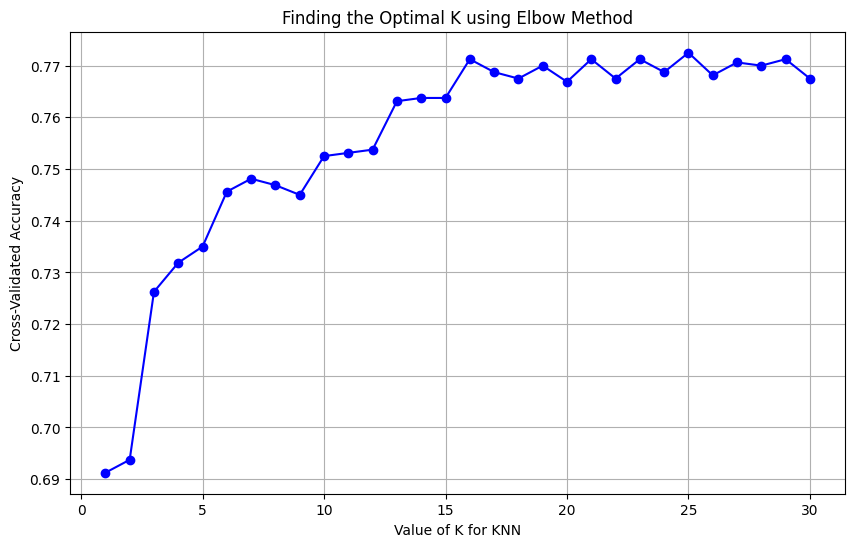

In [59]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n=== Finding Optimal K ===")
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Finding the Optimal K using Elbow Method')
plt.grid(True)
plt.show()


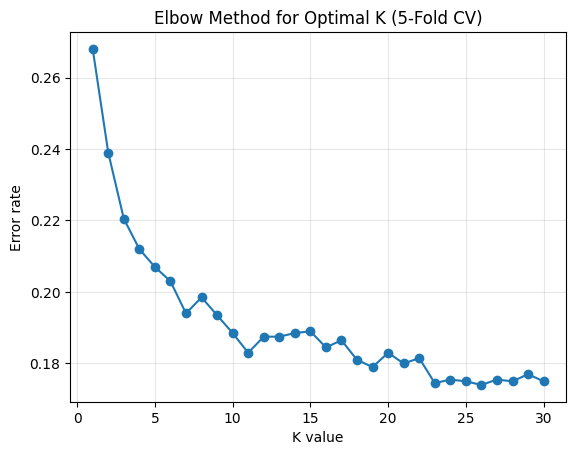

In [66]:
from sklearn.model_selection import cross_val_score

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"] if mobile_data["PriceRange"].dtype in ['int64', 'float64'] else \
    mobile_data["PriceRange"].map({"Low":0, "Medium":1, "High":2, "VeryHigh":3})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

errors = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    # Use 5-fold cross-validation
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    errors.append(1 - scores.mean())

plt.plot(k_values, errors, marker='o')
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.title("Elbow Method for Optimal K (5-Fold CV)")
plt.grid(True, alpha=0.3)
plt.show()

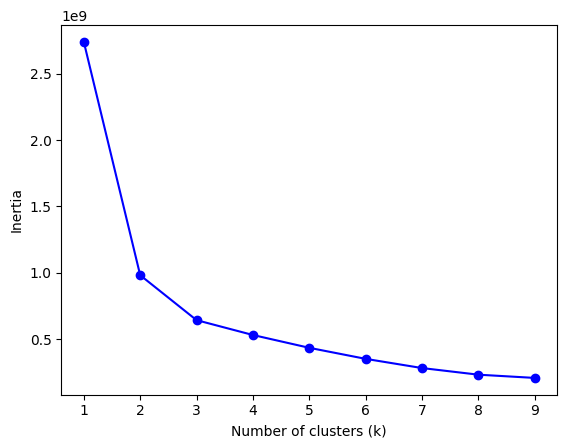

In [88]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 10)  # try different cluster numbers
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


In [96]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]

k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X, y, cv=5).mean()  # 5-fold CV
    scores.append(score)

best_k = k_range[np.argmax(scores)]
print("Best k:", best_k)

Best k: 13


Best k: 13


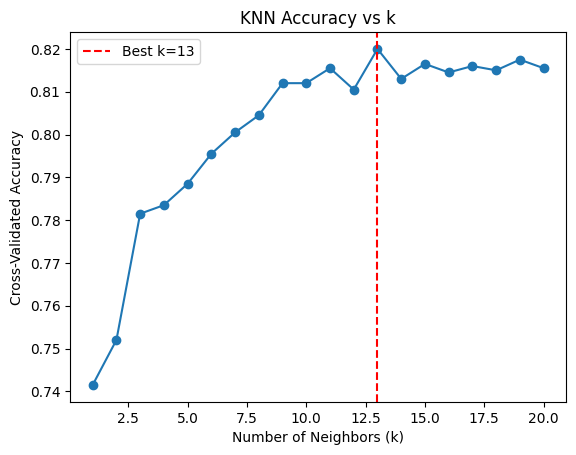

In [97]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]

k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X, y, cv=5).mean()  # 5-fold CV
    scores.append(score)

best_k = k_range[np.argmax(scores)]
print("Best k:", best_k)

# Plot
plt.plot(k_range, scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Accuracy vs k")
plt.axvline(best_k, color='r', linestyle='--', label=f"Best k={best_k}")
plt.legend()
plt.show()


In [103]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]

# --- 2. Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split( # 80 - 20
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Define the Value of k ---
k = 13
print(f"Using k = {k} for the k-NN model.")

# --- 4. Initialize and Train the k-NN Model ---
knn_model = KNeighborsClassifier(n_neighbors=k)

# Train the model using the training data
knn_model.fit(X_train, y_train)
print("k-NN model trained successfully.")

# --- 5. Make Predictions ---
y_pred = knn_model.predict(X_test)

# --- 6. Evaluate the Model ---
accuracy = accuracy_score(y_test, y_pred)
print("-" * 30)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")
print("-" * 30)

Using k = 13 for the k-NN model.
k-NN model trained successfully.
------------------------------
Model Accuracy on Test Set: 0.7950
------------------------------


Decision trees

In [104]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]

print(f"Features used (X): {list(X.columns)}")
print(f"Target variable (y): {y.name}")
print(f"Number of samples: {len(mobile_data)}")

# --- 3. Split Data ---
# Standard split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Initialize and Train the Decision Tree Model (Eager Learning) ---
# The model is built entirely here, defining all rules/splits based on the data.
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# **Training Phase (Eager Learning happens here)**
dt_classifier.fit(X_train, y_train)
print("\nDecision Tree model trained successfully (Eager learning complete: rules defined).")

# --- 5. Make Predictions ---
y_pred = dt_classifier.predict(X_test)

# --- 6. Evaluate the Model ---
accuracy = accuracy_score(y_test, y_pred)
print("-" * 60)
print(f"Decision Tree Accuracy on Test Set: {accuracy:.4f}")
print("-" * 60)

# --- 7. Example Prediction for a New Phone ---
# New phone: 3500 mAh battery, 4096 MB (4GB) RAM
new_phone = pd.DataFrame([[3500, 4096]], columns=["BatteryPower", "RAM"])

# Make a prediction
prediction = dt_classifier.predict(new_phone)[0]
print(f"New phone (Battery: 3500, RAM: 4096) predicted PriceRange (0-3): {prediction}")

Features used (X): ['BatteryPower', 'RAM']
Target variable (y): PriceRange
Number of samples: 2000

Decision Tree model trained successfully (Eager learning complete: rules defined).
------------------------------------------------------------
Decision Tree Accuracy on Test Set: 0.7775
------------------------------------------------------------
New phone (Battery: 3500, RAM: 4096) predicted PriceRange (0-3): VeryHigh


In [106]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. Define the Hyperparameter Grid ---
# We select key hyperparameters that control the complexity of the tree.
param_grid = {
    # Maximum depth of the tree
    'max_depth': [3, 5, 7, 10, None],  # None means unconstrained
    # Minimum number of samples required to split an internal node
    'min_samples_split': [2, 5, 10],
    # Minimum number of samples required to be at a leaf node
    'min_samples_leaf': [1, 2, 4],
    # Function to measure the quality of a split (Gini impurity or Entropy)
    'criterion': ['gini', 'entropy']
}

# --- 3. Perform Grid Search with Cross-Validation (Tuning) ---
dt_base = DecisionTreeClassifier(random_state=42)

# GridSearchCV systematically tests every combination in param_grid
# using 5-fold cross-validation (cv=5) on the training data.
grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 # Use all processors for faster computation
)

# Train the GridSearchCV object (this runs the tuning process)
grid_search.fit(X_train, y_train)
print("Grid Search complete. Best hyperparameters found.")

# --- 4. Retrieve and Evaluate the Tuned Model ---
# Get the model with the best parameters found by the search
tuned_dt_classifier = grid_search.best_estimator_

print("\n" + "=" * 50)
print("🏆 Best Hyperparameters Found:")
print(grid_search.best_params_)
print("=" * 50)

# Make predictions using the tuned model on the unseen test data
y_pred_tuned = tuned_dt_classifier.predict(X_test)

# Calculate the accuracy of the tuned model
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

# --- 5. Comparison ---
# For comparison, let's get the accuracy of the default model (max_depth=5 from previous example)
default_dt = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
default_accuracy = accuracy_score(y_test, default_dt.predict(X_test))

print(f"\nDefault Model Accuracy: {default_accuracy:.4f}")
print(f"Tuned Model Accuracy:   {tuned_accuracy:.4f}")

# Check if tuning improved the accuracy
if tuned_accuracy > default_accuracy:
    print(f"\n✅ Tuning resulted in an accuracy increase of: {(tuned_accuracy - default_accuracy):.4f}")
elif tuned_accuracy < default_accuracy:
    print("\n⚠️ Tuning resulted in a slight decrease in accuracy (may indicate the default parameters were already near optimal).")
else:
    print("\n↔️ Tuning did not change the accuracy (default parameters were optimal among the tested grid).")

Grid Search complete. Best hyperparameters found.

🏆 Best Hyperparameters Found:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}

Default Model Accuracy: 0.7775
Tuned Model Accuracy:   0.7875

✅ Tuning resulted in an accuracy increase of: 0.0100


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
    disp.plot(cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()
